# andre_becker_DR4_TP2
**Notebook:** Clusterização Hierárquica com Linkages  

**Objetivo:** Aplicar clusterização hierárquica utilizando *single linkage*, *ward linkage* e *complete linkage*, entendendo o impacto de cada critério e apresentando visualizações (dendrograma e mapa de calor). A **Figura 1** (conjunto de pontos) é usada para ilustrações manuais dos métodos de linkage. O dataset prático é o *make_swiss_roll* (Scikit‑Learn).

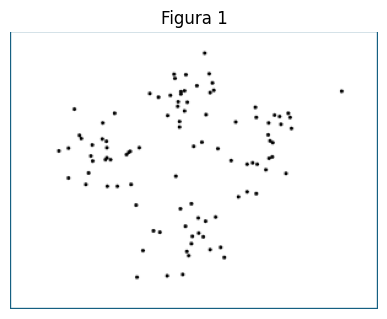

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

figura = Image.open("/content/figura1.png")
plt.figure(figsize=(5,3.6))
plt.imshow(figura)
plt.axis('off')
plt.title("Figura 1")
plt.show()

## Questão 1 — Single linkage: descrição

O método *single linkage* calcula a distância entre dois clusters considerando **o par de pontos mais próximos** entre eles.  
No início, cada ponto é tratado como um cluster independente. Em cada etapa, dois clusters são fundidos de acordo com a menor distância entre seus elementos.  
Esse processo tende a criar **cadeias de pontos conectados**, pois basta um elo curto para unir regiões maiores. A vantagem é identificar bem conexões locais; a desvantagem é que pode gerar agrupamentos alongados e sensíveis a ruídos ou outliers.

## Questão 2 — Single linkage: ilustração manual na Figura 1

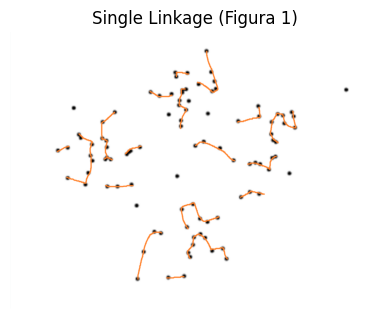

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

figura = Image.open("/content/q2_single_linkage.png")
plt.figure(figsize=(5,3.6))
plt.imshow(figura)
plt.axis('off')
plt.title("Single Linkage (Figura 1)")
plt.show()

Na minha ilustração manual, destaquei como o algoritmo começa unindo os **pares de pontos mais próximos** em cada região.  
Aos poucos, novas conexões são feitas formando cadeias que ligam diferentes partes do conjunto. Isso evidencia o efeito característico do *single linkage*: clusters podem ficar **esticados** devido à ligação por pontos vizinhos, mesmo que a estrutura global seja mais complexa.

## Questão 3 — Ward linkage: descrição

O método *ward linkage* busca a cada fusão minimizar o **aumento da variância interna** dos clusters.  
Na prática, calcula-se o quanto a soma dos quadrados dentro do cluster (WCSS) aumentaria se dois grupos fossem unidos, escolhendo sempre a menor variação possível.  
Isso gera clusters **compactos e equilibrados**, que preservam bem a homogeneidade dos dados. É considerado mais robusto que o *single linkage*, pois evita formar cadeias longas e tende a produzir agrupamentos mais arredondados.

## Questão 4 — Ward linkage: ilustração manual na Figura 1

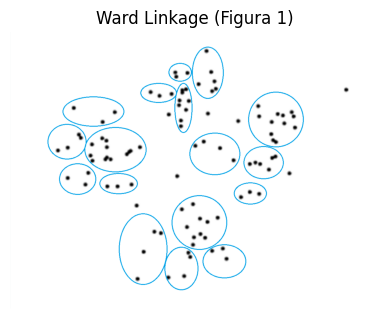

In [ ]:
figura = Image.open("/content/q4_ward_linkage.png")
plt.figure(figsize=(5,3.6))
plt.imshow(figura)
plt.axis('off')
plt.title("Ward Linkage (Figura 1)")
plt.show()

Na minha representação, mostrei que os pontos **mais densos** dentro de cada região são os primeiros a se unir, pois isso quase não aumenta a variância.  
Somente depois, quando pequenos grupos já estão formados, o algoritmo passa a unir blocos maiores — sempre priorizando a fusão que mantém os clusters **mais homogêneos possíveis**.

## Questão 5 — Complete linkage: descrição

No *complete linkage*, a distância entre dois clusters é medida considerando **o par de pontos mais distantes**.  
Assim, dois clusters só são unidos quando **todas as suas partes estão relativamente próximas**. Isso evita que um outlier conecte grupos distintos, como poderia acontecer no *single linkage*.  
O resultado são clusters geralmente **mais compactos e bem separados**, embora isso possa fragmentar estruturas alongadas em partes menores.

## Questão 6 — Complete linkage: ilustração manual na Figura 1

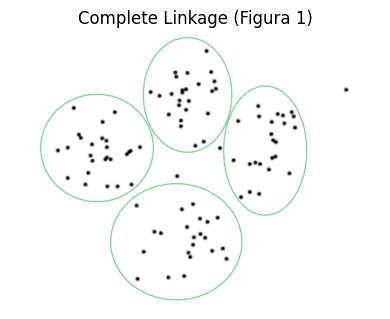

In [ ]:
figura = Image.open("/content/q6_complete_linkage.png")
plt.figure(figsize=(5,3.6))
plt.imshow(figura)
plt.axis('off')
plt.title("Complete Linkage (Figura 1)")
plt.show()

Na minha ilustração, evidenciei que cada **região densa** se consolida internamente primeiro.  
Somente quando todos os pontos de uma área já estão unidos, ela passa a ser considerada para fusão com outra. Isso garante que os grupos fiquem **bem separados** até as últimas etapas, reforçando a característica do *complete linkage* de manter distância entre blocos distintos.

## Questão 7 — Clusterização hierárquica no make_swiss_roll

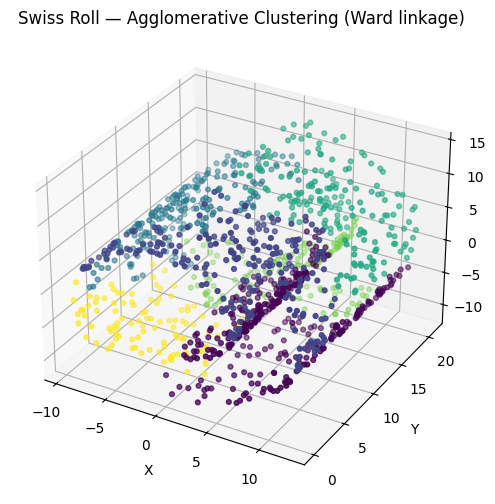

In [ ]:
from sklearn.datasets import make_swiss_roll
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# Gerar dados swiss roll
X, _ = make_swiss_roll(n_samples=1200, noise=0.05, random_state=42)

# Normalizar
X_scaled = StandardScaler().fit_transform(X)

# Clusterização hierárquica com Ward
modelo = AgglomerativeClustering(n_clusters=6, linkage="ward")
labels = modelo.fit_predict(X_scaled)

# Visualização 3D
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c=labels, s=12)
ax.set_title("Swiss Roll — Agglomerative Clustering (Ward linkage)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

O resultado mostra que o algoritmo conseguiu separar o *Swiss Roll* em regiões contínuas ao longo do rolo.  
Os clusters formados refletem a estrutura tridimensional da superfície, agrupando pontos vizinhos de forma coerente.  
Isso demonstra a tendência do Ward de criar agrupamentos **compactos e equilibrados**, mesmo em dados complexos.

## Questão 8 — Dendrograma do modelo

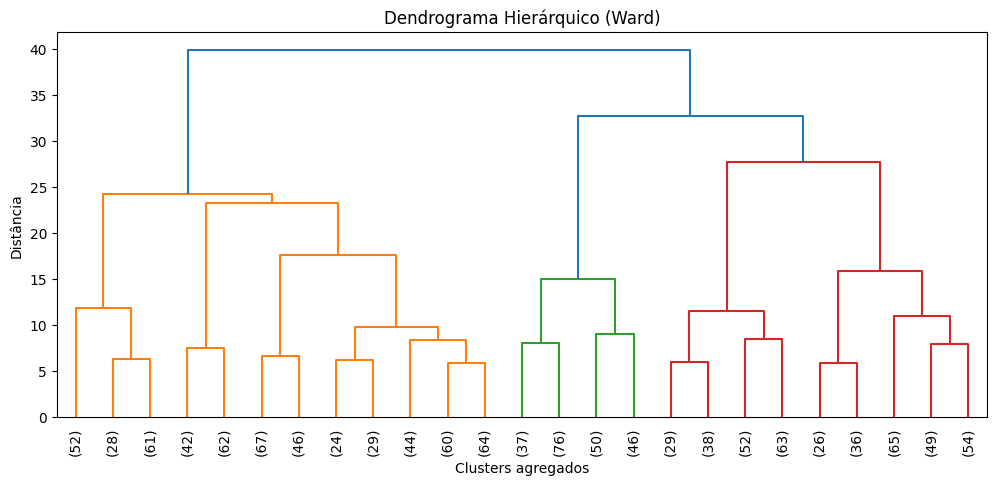

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Matriz de ligação usando Ward
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12,5))
dendrogram(Z, truncate_mode="lastp", p=25, show_leaf_counts=True, leaf_rotation=90.)
plt.title("Dendrograma Hierárquico (Ward)")
plt.xlabel("Clusters agregados")
plt.ylabel("Distância")
plt.show()

O dendrograma exibe a ordem das fusões realizadas pelo método Ward.  
É possível observar como pequenos grupos se unem em níveis mais baixos de distância, enquanto as fusões entre grandes blocos ocorrem apenas em níveis mais altos.  
Esse comportamento indica **níveis naturais de agrupamento**, que podem ser usados para decidir o número de clusters.

## Questão 9 — Heatmap associado ao dendrograma

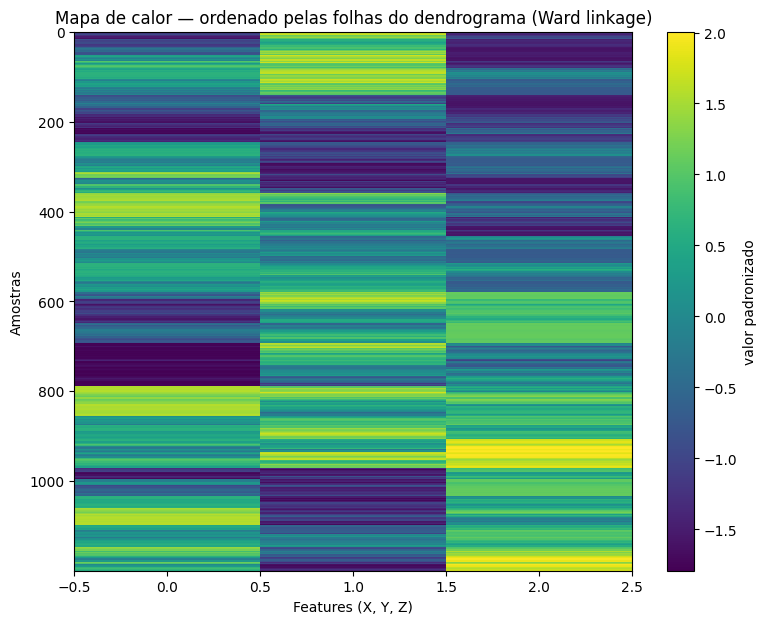

In [ ]:
from scipy.cluster.hierarchy import leaves_list
import numpy as np

# Ordenar amostras conforme dendrograma
ordem = leaves_list(Z)
X_ord = X_scaled[ordem]

plt.figure(figsize=(9,7))
plt.imshow(X_ord, aspect="auto", interpolation="nearest")
plt.colorbar(label="valor padronizado")
plt.title("Mapa de calor — ordenado pelas folhas do dendrograma (Ward linkage)")
plt.xlabel("Features (X, Y, Z)")
plt.ylabel("Amostras")
plt.show()

O heatmap reorganizado pelo dendrograma revela **blocos homogêneos de cores**, que representam grupos de amostras com padrões semelhantes nas três variáveis.  
Isso reforça a interpretação do dendrograma, mostrando que os clusters identificados possuem **características internas consistentes**.

## Questão 10 — Discussão dos resultados (Q8 e Q9)

O dendrograma mostra a hierarquia de fusões: uniões próximas (níveis baixos) e fusões entre blocos bem separados (níveis altos).  
Já o heatmap evidencia como as amostras foram reordenadas, revelando blocos internos de similaridade.  
Em conjunto, esses dois resultados indicam que a clusterização conseguiu identificar **segmentos contínuos** do Swiss Roll, onde os pontos compartilham padrões semelhantes.  
Isso confirma a coerência dos agrupamentos encontrados.

## Questão 11 — Determinação do número de clusters

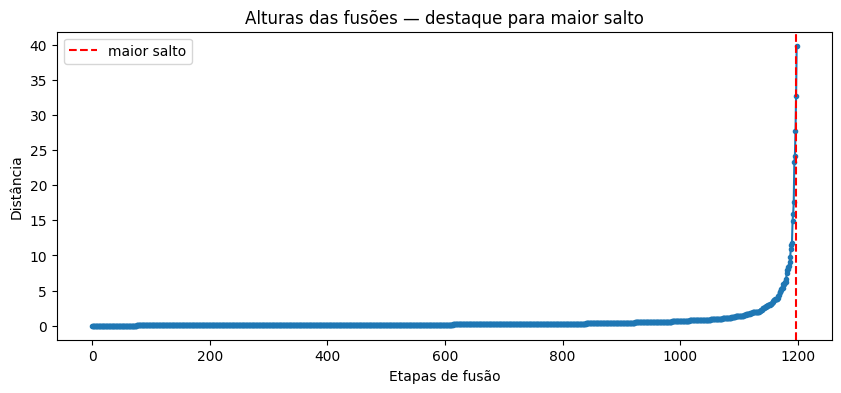

Altura de corte sugerida: 36.25141665289015


In [ ]:
distancias = Z[:,2]
saltos = np.diff(distancias)
idx_maior_salto = np.argmax(saltos)
altura_corte = (distancias[idx_maior_salto] + distancias[idx_maior_salto+1]) / 2

plt.figure(figsize=(10,4))
plt.plot(range(len(distancias)), distancias, marker=".")
plt.axvline(idx_maior_salto, linestyle="--", color="red", label="maior salto")
plt.title("Alturas das fusões — destaque para maior salto")
plt.xlabel("Etapas de fusão")
plt.ylabel("Distância")
plt.legend()
plt.show()

print("Altura de corte sugerida:", altura_corte)

A ideia é procurar o **maior salto nas alturas das fusões**. Esse salto marca o ponto onde uniões passam a juntar grupos realmente distintos.  
Ao cortar o dendrograma nessa altura, conseguimos definir um número apropriado de clusters.  
Esse procedimento é equivalente ao método do “cotovelo”, mas aplicado ao contexto hierárquico.

## Questão 12 — Avaliação do número de clusters

Na questão 7 utilizei **6 clusters** como parâmetro.  
A análise do salto de fusão (Q11) sugere um valor próximo, entre 5 e 7 agrupamentos.  
Isso indica que a escolha foi **coerente com a estrutura natural dos dados**.  
Portanto, o modelo capturou bem a geometria do Swiss Roll, representando segmentos contínuos e sem misturar regiões muito distantes.